# More Pandas Practice: Combining Data, Binning, and Pivot Tables

This notebook gives you practice applying the tools from `02_Combining_Dataframes.ipynb`: joining and concatenating DataFrames with `.join()` and `pd.concat()`, binning continuous data into categories with `pd.cut()`, and summarising data with `pd.pivot_table()`. You will work with the red and white wine quality datasets throughout — loading, combining, filtering, and pivoting them to answer realistic data questions.

---

## Starter Code

In [1]:
# Import pandas and load both wine datasets — run this cell first
import pandas as pd

red_df = pd.read_csv('../data/winequality-red.csv', delimiter=';')
white_df = pd.read_csv('../data/winequality-white.csv', delimiter=';')

print('Red wine shape:', red_df.shape)
print('White wine shape:', white_df.shape)

Red wine shape: (1599, 12)
White wine shape: (4898, 12)


---

## Part 1 — Loading and Inspecting

### Challenge 1: Sense-check the data

Use DataFrame attributes and methods to confirm both datasets loaded correctly. Check:

- The number of rows and columns in each

- The data types of the columns

- Whether any columns contain null values

In [ ]:
# print(red_df.columns)
# print(white_df.columns)

# print(red_df.info)
# print()
# print(white_df.info)

#print(red_df.dtypes)
#print()
#print(white_df.dtypes)

#print(red_df.isna)

print("number of null values in red: ",red_df.isna().sum().sum())

print("number of null values in white: ", white_df.isna().sum().sum())

number of null values in red:  0
number of null values in white:  0


---

## Part 2 — Filtering by Alcohol Content

### Challenge 2: Flag above-average alcohol

You want to avoid wines with above-average alcohol content. To do this:

1. Find the **mean alcohol content** separately for reds and whites.

2. Create a **boolean `Series`** for each DataFrame indicating whether each row has an alcohol content above the mean.

3. Attach this boolean `Series` to each DataFrame — do it **twice**: once using `.join()` and once using `pd.concat(..., axis=1)`.

4. Filter each DataFrame to return only the rows where alcohol is **above** the mean.

In [ ]:
# Step 1: Calculate mean alcohol for each wine type
red_df_mean = red_df['alcohol'].mean()
white_df_mean = white_df['alcohol'].mean()

print("red_df_mean: ", red_df_mean)
print("white_df_mean: ", white_df_mean)

red_df_mean:  10.422983114446529
white_df_mean:  10.514267047774602


In [71]:
# Step 2: Create boolean Series — True where alcohol is above the mean

red_df_alcohol_above = red_df['alcohol'] > red_df_mean
print(red_df_alcohol_above)

white_df_alcohol_above = white_df['alcohol'] > white_df_mean
print(white_df_alcohol_above)


0       False
1       False
2       False
3       False
4       False
        ...  
1594     True
1595     True
1596     True
1597    False
1598     True
Name: alcohol, Length: 1599, dtype: bool
0       False
1       False
2       False
3       False
4       False
        ...  
4893     True
4894    False
4895    False
4896     True
4897     True
Name: alcohol, Length: 4898, dtype: bool


In [23]:
# Step 3a: Attach using .join()

join_red_df_alcohol_above = red_df.join(red_df_alcohol_above.rename('alcohol_above_mean'))
join_red_df_alcohol_above.head(15)

join_white_df_alcohol_above = white_df.join(white_df_alcohol_above.rename('alcohol_above_mean'))
join_white_df_alcohol_above.head(15)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_above_mean
0,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,False
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,False
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,False
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False
5,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,False
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,False
7,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,False
8,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,False
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,True


In [ ]:
# Step 3b: Attach using pd.concat(..., axis=1)
#concat_red_df_alcohol_above = pd.concat([red_df, red_df_alcohol_above.rename('alcohol_above_mean')], axis=1)
#concat_red_df_alcohol_above.head(15)

concat_white_df_alcohol_above = pd.concat([white_df, white_df_alcohol_above.rename('alcohol_above_mean')], axis=1)
concat_white_df_alcohol_above.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_above_mean
0,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,False
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,False
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,False
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False
5,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,False
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,False
7,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,False
8,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,False
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,True


In [73]:
# Step 4: Filter to only rows where alcohol is above the mean
# filtered_red_df = join_red_df_alcohol_above.query('alcohol_above_mean == True')
# filtered_red_df.shape  #head(15)

filtered_white_df = join_white_df_alcohol_above.query('alcohol_above_mean == True')
filtered_white_df.shape  #head(15)
filtered_white_df.head(20)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_above_mean
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,True
10,8.1,0.27,0.41,1.45,0.033,11.0,63.0,0.9908,2.99,0.56,12.0,5,True
12,7.9,0.18,0.37,1.20,0.040,16.0,75.0,0.9920,3.18,0.63,10.8,5,True
13,6.6,0.16,0.40,1.50,0.044,48.0,143.0,0.9912,3.54,0.52,12.4,7,True
15,6.6,0.17,0.38,1.50,0.032,28.0,112.0,0.9914,3.25,0.55,11.4,7,True
17,6.2,0.66,0.48,1.20,0.029,29.0,75.0,0.9892,3.33,0.39,12.8,8,True
18,7.4,0.34,0.42,1.10,0.033,17.0,171.0,0.9917,3.12,0.53,11.3,6,True
20,6.2,0.66,0.48,1.20,0.029,29.0,75.0,0.9892,3.33,0.39,12.8,8,True
21,6.4,0.31,0.38,2.90,0.038,19.0,102.0,0.9912,3.17,0.35,11.0,7,True
28,7.4,0.27,0.48,1.10,0.047,17.0,132.0,0.9914,3.19,0.49,11.6,6,True


---

## Part 3 — Binning by Acidity

### Challenge 3: Bin by fixed acidity

You want to avoid wines with the highest acidity. To do this:

1. Use `pd.cut()` to divide the `fixed acidity` column of each DataFrame into **5 equal-width bins**.

2. Attach the resulting bin `Series` to each original DataFrame — once using `.join()` and once using `pd.concat(..., axis=1)`.

3. Filter each DataFrame to return only rows that are **not** in the top acidity bin.

> Note: equal-width bins divide the *range* of values into equal intervals. They are different from quintiles (equal-count bins).

In [40]:
# Step 1: Create 5 equal-width acidity bins for red and white wines

fa_red_bins = pd.cut(red_df['fixed acidity'], bins=5)
fa_red_bins.head(10)

fa_white_bins = pd.cut(white_df['fixed acidity'], bins=5)
fa_white_bins.head(10)

fa_red_bins.value_counts().sort_index()
#fa_white_bins.value_counts().sort_index()


fixed acidity
(4.589, 6.86]     274
(6.86, 9.12]      913
(9.12, 11.38]     298
(11.38, 13.64]    102
(13.64, 15.9]      12
Name: count, dtype: int64

In [96]:
# Step 2a: Attach bins using .join()
red_df_acidity_bins = red_df.join(fa_red_bins.rename('acidity_bins'))
red_df_acidity_bins.head(15)

white_df_acidity_bins = white_df.join(fa_white_bins.rename('acidity_bins'))
white_df_acidity_bins.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acidity_bins
0,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,"(5.88, 7.96]"
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,"(5.88, 7.96]"
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,"(7.96, 10.04]"
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,"(5.88, 7.96]"
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,"(5.88, 7.96]"
5,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,"(7.96, 10.04]"
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,"(5.88, 7.96]"
7,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,"(5.88, 7.96]"
8,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,"(5.88, 7.96]"
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,"(7.96, 10.04]"


In [97]:
# Step 2b: Attach bins using pd.concat(..., axis=1)
red_df_acidity_bins_conc = pd.concat(
    [red_df, fa_red_bins.rename('acidity_bins')],
    axis=1
)
red_df_acidity_bins_conc.head()

white_df_acidity_bins_conc = pd.concat(
    [white_df, fa_white_bins.rename('acidity_bins')],
    axis=1
)
white_df_acidity_bins_conc.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acidity_bins
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,"(5.88, 7.96]"
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,"(5.88, 7.96]"
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,"(7.96, 10.04]"
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,"(5.88, 7.96]"
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,"(5.88, 7.96]"


In [98]:
# Step 3: Filter out the top acidity bin from each DataFrame
top_bin_red = red_df_acidity_bins['acidity_bins'].cat.categories[-1]
print (top_bin_red)

top_bin_white = white_df_acidity_bins['acidity_bins'].cat.categories[-1]
print (top_bin_white)

red_df_filtered = red_df_acidity_bins[red_df_acidity_bins['acidity_bins'] != top_bin_red]
red_df_filtered.head(15)
white_df_filtered = white_df_acidity_bins[white_df_acidity_bins['acidity_bins'] != top_bin_white]
white_df_filtered.head(15)

(13.64, 15.9]
(12.12, 14.2]


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acidity_bins
0,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,"(5.88, 7.96]"
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,"(5.88, 7.96]"
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,"(7.96, 10.04]"
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,"(5.88, 7.96]"
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,"(5.88, 7.96]"
5,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,"(7.96, 10.04]"
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,"(5.88, 7.96]"
7,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,"(5.88, 7.96]"
8,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,"(5.88, 7.96]"
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,"(7.96, 10.04]"


---

## Part 4 — Pivot Tables

### Challenge 4: Alcohol by quality — pivot table

You want to understand how avoiding above-average alcohol affects the quality of wines available to you.

Using the **above-average alcohol** subsets from Challenge 2, create a **pivot table** for each wine type showing:

- The **average `alcohol` content** as the value

- **`quality`** as the index

This should give you one row per quality level and the average alcohol content for that group.

In [ ]:
# Pivot table for red wines above mean alcohol — average alcohol by quality

#filtered_white_df.head(20)

print("mean / alcohol (only above overall mean alcohol in red wines)")

pivot_red = pd.pivot_table(
    filtered_red_df,
    values='alcohol',
    index='quality',
    aggfunc='mean'
)
pivot_red


mean alcohol (only above overall mean alcohol red wines)


,alcohol
quality,
3,10.866667
4,11.295000
5,11.088686
6,11.437214
7,11.708236
8,12.368750


In [ ]:
# Pivot table for white wines above mean alcohol — average alcohol by quality

print("mean / alcohol (only above overall mean alcohol in white wines)")

pivot_white = pd.pivot_table(
    filtered_white_df,
    values='alcohol',
    index='quality',
    aggfunc='mean'
)
pivot_white

mean alcohol (only above overall mean alcohol white wines)


,alcohol
quality,
3,11.525000
4,11.425532
5,11.211099
6,11.604366
7,11.924761
8,12.139437
9,12.625000


### Challenge 5: Alcohol by quality and acidity bin — pivot table

Now do the same for the **non-top-acidity** subsets from Challenge 3. Create a pivot table for each wine type showing:

- The **average `alcohol` content** as the value

- **`quality`** as the index

- **`fixed acidity` bin** as the columns

This lets you see average alcohol broken down by both quality score and acidity category.

In [101]:
# Pivot table for red wines — average alcohol by quality and acidity bin

#red_df_filtered.columns
#red_df_filtered.head(15)

pivot_red = pd.pivot_table(
    red_df_filtered,
    values='alcohol',
    index='quality',
    columns='acidity_bins',
    aggfunc='mean'
)
pivot_red

acidity_bins,"(4.589, 6.86]","(6.86, 9.12]","(9.12, 11.38]","(11.38, 13.64]"
quality,,,,
3,9.875000,10.500000,9.150000,9.000000
4,11.006667,9.981667,9.920000,9.966667
5,10.304245,9.773727,9.846429,10.229630
6,11.223529,10.431985,10.687395,10.480952
7,12.195402,11.486413,11.383333,10.809524
8,13.633333,11.937500,11.916667,9.800000


In [103]:
# Pivot table for white wines — average alcohol by quality and acidity bin

#white_df_filtered.columns
#white_df_filtered.head(15)

pivot_white = pd.pivot_table(
    white_df_filtered,
    values='alcohol',
    index='quality',
    columns='acidity_bins',
    aggfunc='mean'
)
pivot_white

acidity_bins,"(3.79, 5.88]","(5.88, 7.96]","(7.96, 10.04]","(10.04, 12.12]"
quality,,,,
3,9.850000,10.472727,10.540000,9.65
4,10.786364,10.102564,10.126471,9.90
5,10.136635,9.732173,10.176452,9.70
6,10.902765,10.529056,10.635247,9.50
7,12.021405,11.303724,10.988679,NaN
8,12.403030,11.486364,11.080000,NaN
9,NaN,12.625000,10.400000,NaN


In [102]:
# Attach bins to the not-top-acidity subsets from Challenge 3
# (Re-create them here cleanly for self-contained execution)
red_df_b   = red_df.copy()
white_df_b = white_df.copy()

red_df_b['acidity_bin']   = pd.cut(red_df_b['fixed acidity'], bins=5)
white_df_b['acidity_bin'] = pd.cut(white_df_b['fixed acidity'], bins=5)

# Exclude top bin
red_sub   = red_df_b[red_df_b['acidity_bin'] != red_df_b['acidity_bin'].max()]
white_sub = white_df_b[white_df_b['acidity_bin'] != white_df_b['acidity_bin'].max()]

# Pivot: average alcohol by quality (rows) and acidity bin (columns)
print('Red wines — average alcohol by quality and acidity bin:')
print(pd.pivot_table(red_sub, values='alcohol',
                     index='quality', columns='acidity_bin', aggfunc='mean'))

print('\nWhite wines — average alcohol by quality and acidity bin:')
print(pd.pivot_table(white_sub, values='alcohol',
                     index='quality', columns='acidity_bin', aggfunc='mean'))

Red wines — average alcohol by quality and acidity bin:
acidity_bin  (4.589, 6.86]  (6.86, 9.12]  (9.12, 11.38]  (11.38, 13.64]
quality                                                                
3                 9.875000     10.500000       9.150000        9.000000
4                11.006667      9.981667       9.920000        9.966667
5                10.304245      9.773727       9.846429       10.229630
6                11.223529     10.431985      10.687395       10.480952
7                12.195402     11.486413      11.383333       10.809524
8                13.633333     11.937500      11.916667        9.800000

White wines — average alcohol by quality and acidity bin:
acidity_bin  (3.79, 5.88]  (5.88, 7.96]  (7.96, 10.04]  (10.04, 12.12]
quality                                                               
3                9.850000     10.472727      10.540000            9.65
4               10.786364     10.102564      10.126471            9.90
5               10.136635

---

## Part 5 — Open Exploration

### Challenge 6: Your own question

Set a 10-minute timer. Pick one question about the wine data that interests you and answer it using any combination of the tools from this notebook (filtering, joining, binning, pivot tables, groupby, visualisation). Be ready to explain what you found and why you chose that question.

Red wine correlation: 0.013731637340066292
White wine correlation: -0.09757682889469298
Red wine residual sugar mean per quality levels: quality
3    2.635000
4    2.694340
5    2.528855
6    2.477194
7    2.720603
8    2.577778
Name: residual sugar, dtype: float64
White wine residual sugar mean per quality levels: quality
3    6.392500
4    4.628221
5    7.334969
6    6.441606
7    5.186477
8    5.671429
9    4.120000
Name: residual sugar, dtype: float64


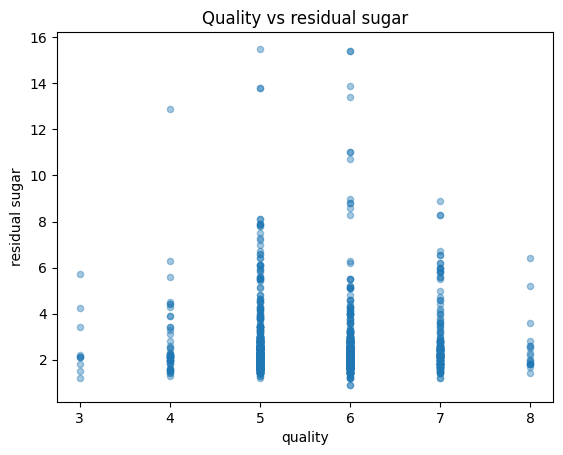

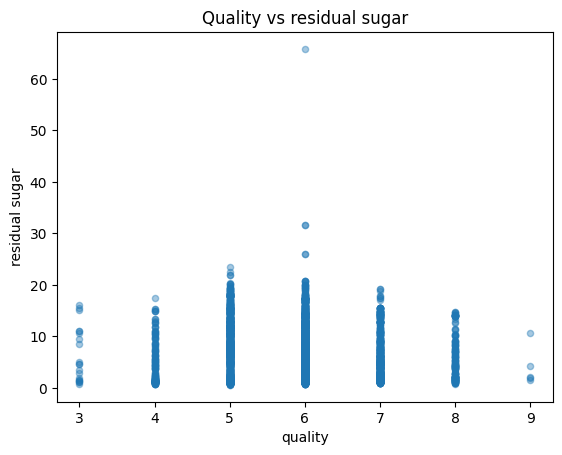

In [ ]:
import matplotlib.pyplot as plt

#Does the quality of the red wine depend more on the residual sugar than in white wines?

# red wine shows very weak correlation: residual sugar decreases quality in less proportion than in white wines
# white wine a negative correlation, then more residual sugar tends to slightly decrease quality

# But, residual sugar does not strongly determine quality of both wines

#red_df.head(20)

red_corr = red_df["residual sugar"].corr(red_df["quality"])
white_corr = white_df["residual sugar"].corr(white_df["quality"])

print("Red wine correlation:", red_corr)
print("White wine correlation:", white_corr)

red_mean = red_df.groupby("quality")["residual sugar"].mean()
white_mean = white_df.groupby("quality")["residual sugar"].mean()

print("Red wine residual sugar mean per quality levels:", red_mean)
print("White wine residual sugar mean per quality levels:", white_mean)

red_df.plot(kind='scatter', x='quality', y='residual sugar',
        title='Quality vs residual sugar', alpha=0.4)
plt.show()

white_df.plot(kind='scatter', x='quality', y='residual sugar',
        title='Quality vs residual sugar', alpha=0.4)
plt.show()
